In [1]:
# これはQ学習を試すnotebookです。

In [3]:
import numpy as np

In [4]:
reward = np.array(
    [
        [0, 1, 0, 1, 0, 0, 0, 0, 0],  # 0から1,3に移動できるので、そこに1
        [1, 0, 1, 0, 0, 0, 0, 0, 0],  # 1から0,2に移動できるので、そこに1
        [0, 1, 0, 0, 0, 1, 0, 0, 0],
        [1, 0, 0, 0, 1, 0, 1, 0, 0],
        [0, 0, 0, 1, 0, 1, 0, 1, 0],
        [0, 0, 1, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 10000],  # 8がゴールのため7→8の報酬を大きく
        [0, 0, 0, 0, 0, 0, 0, 1, 0],
    ]
)

In [5]:
Q = np.array(np.zeros(reward.shape))


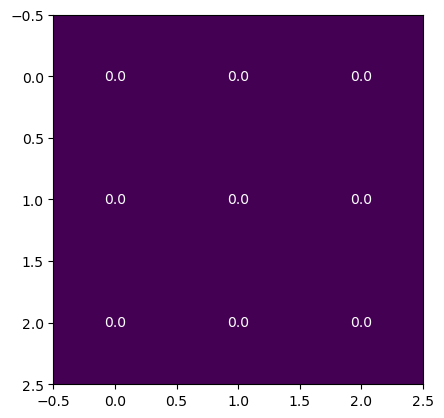

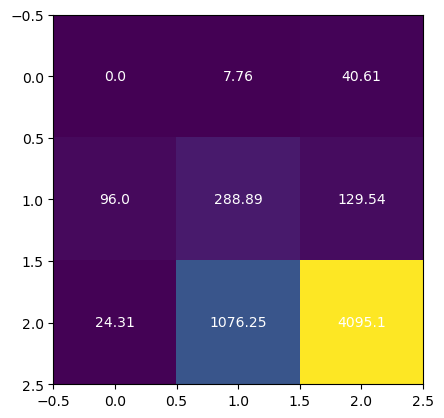

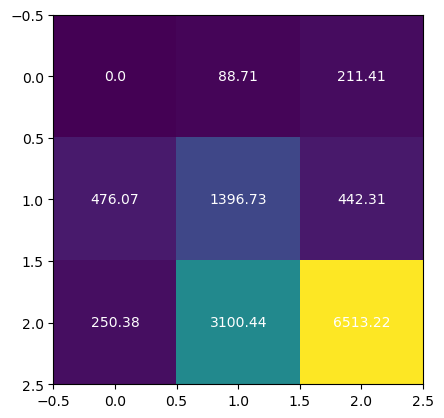

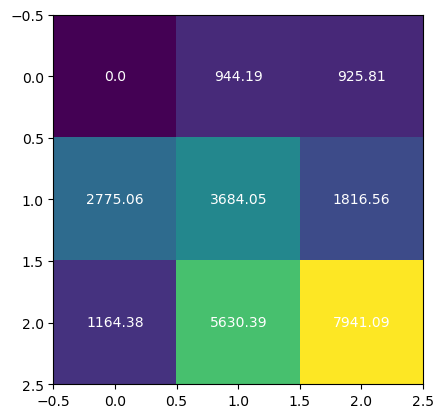

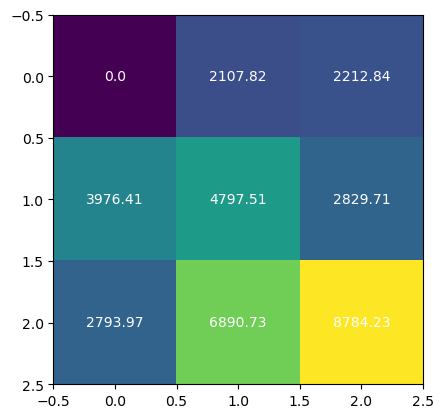

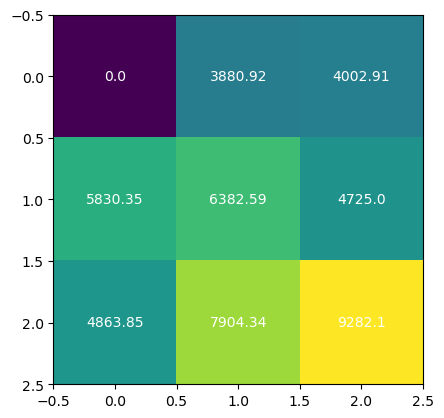

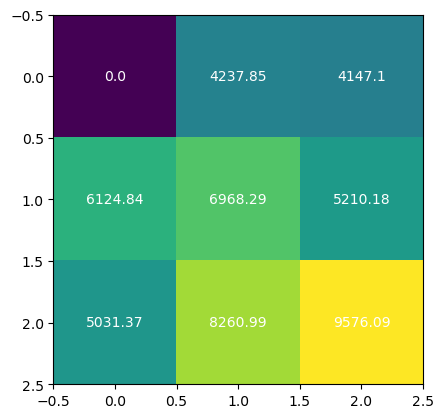

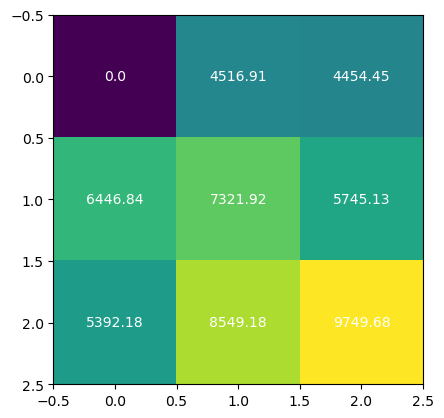

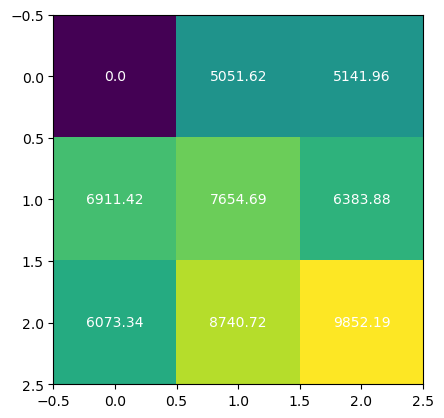

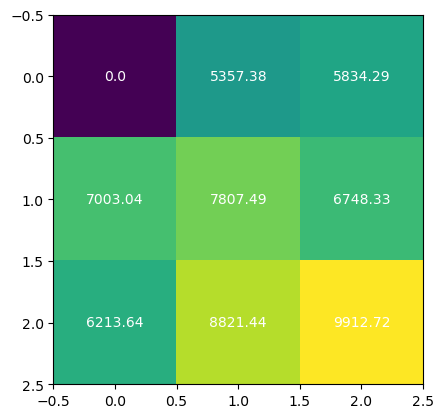

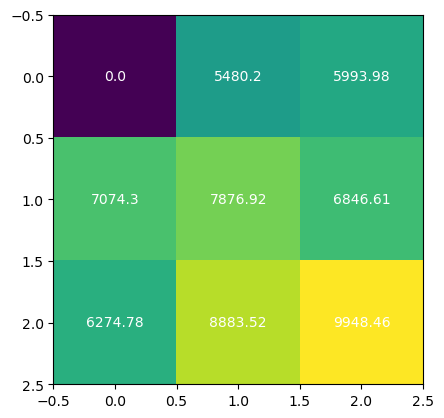

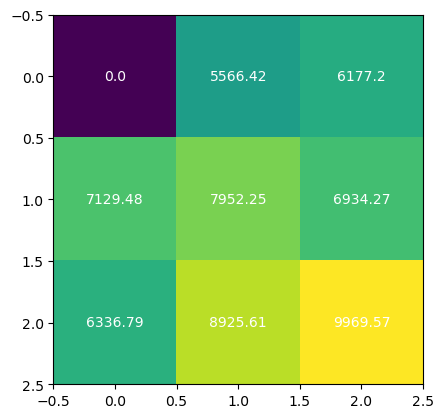

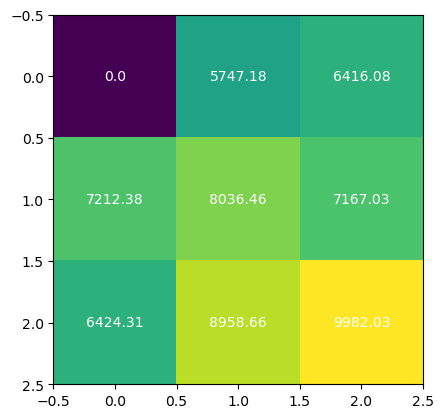

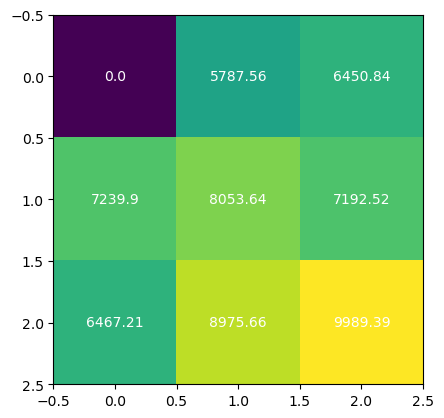

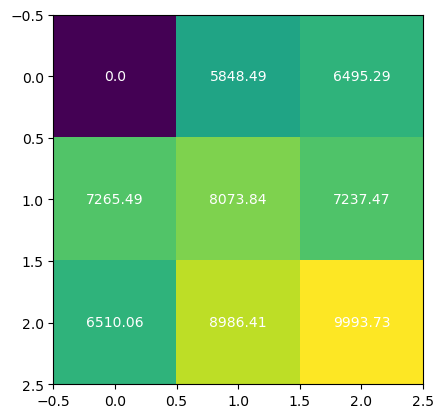

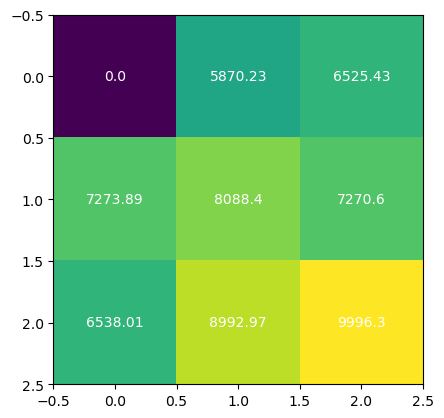

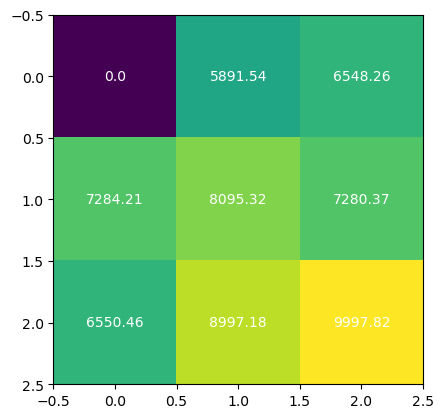

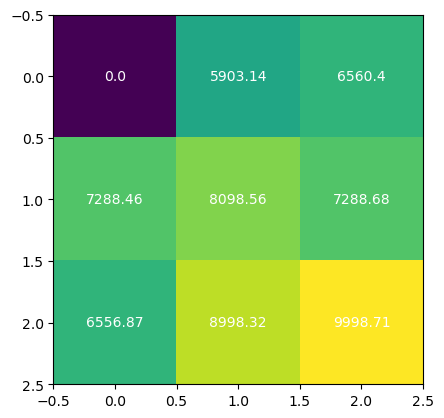

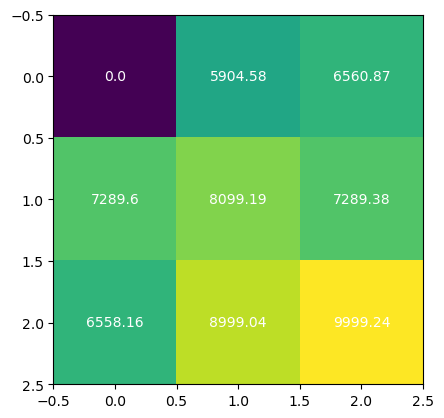

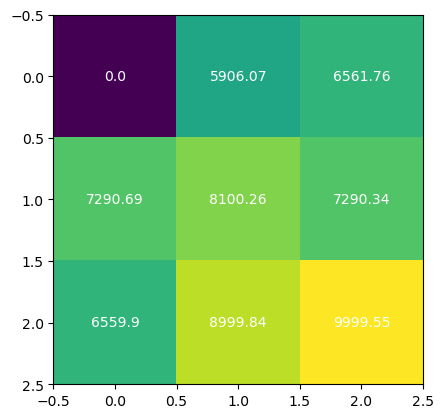

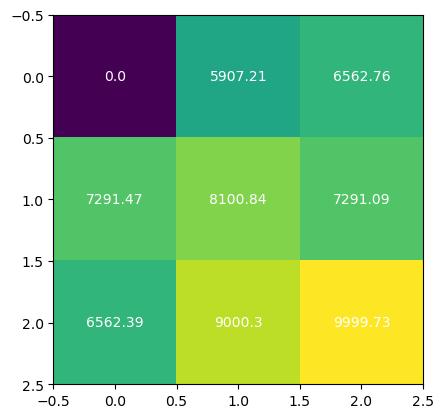

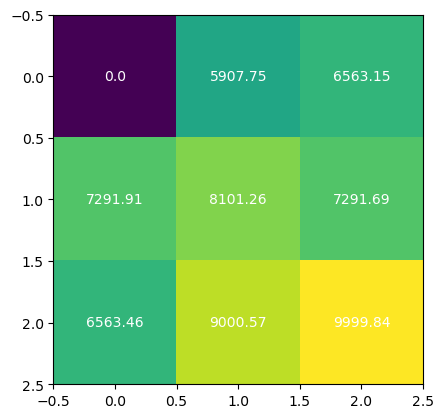

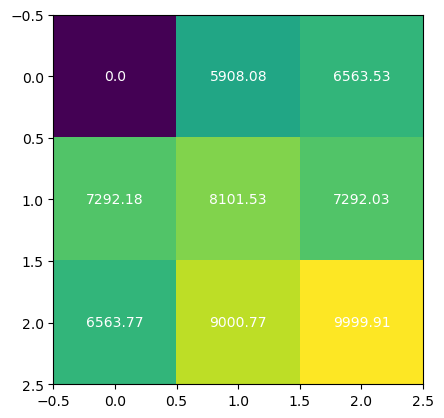

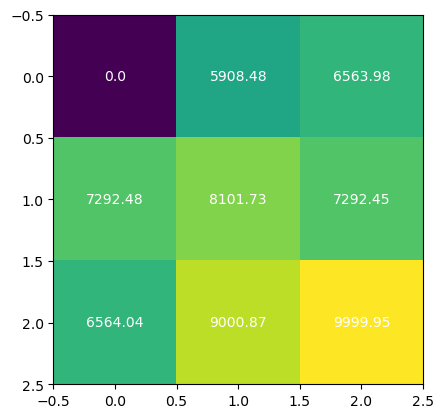

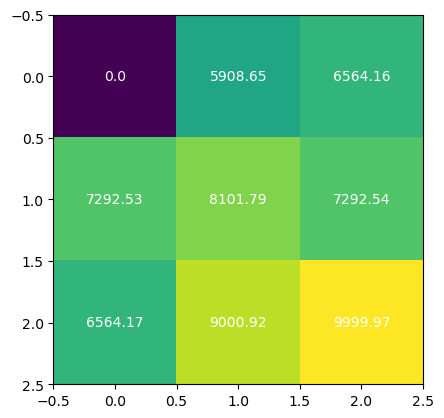

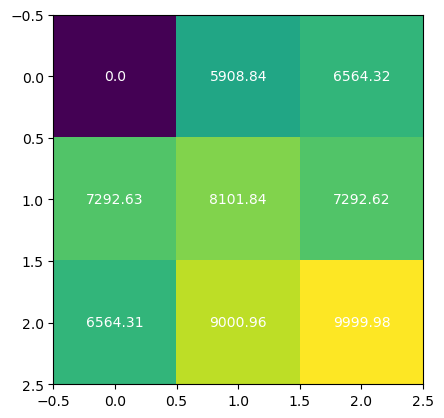

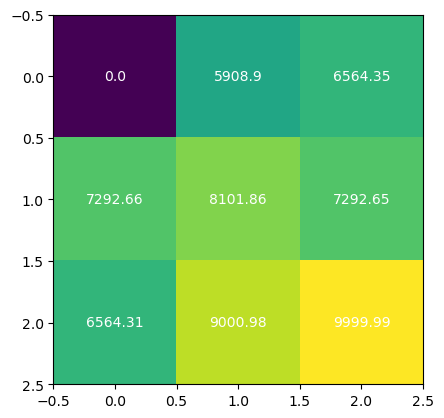

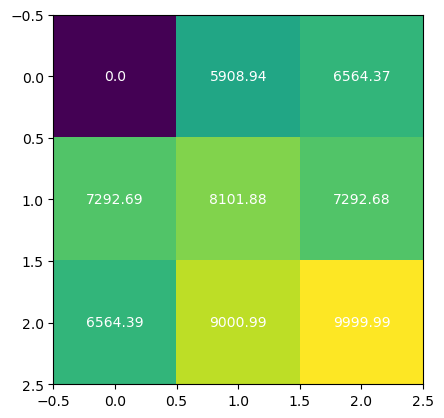

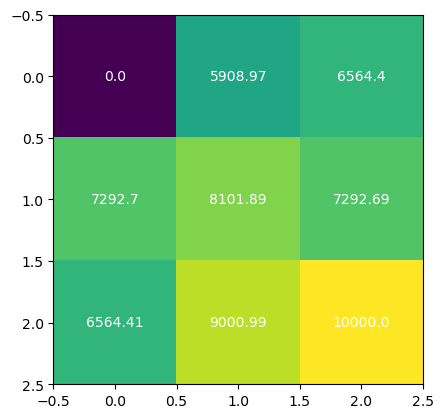

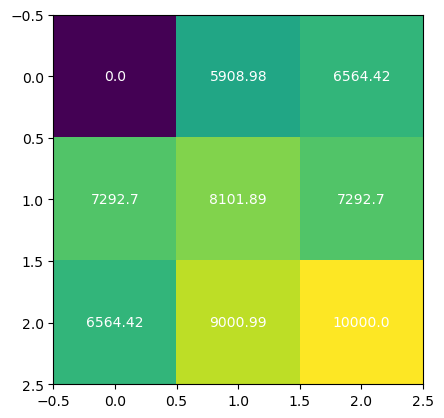

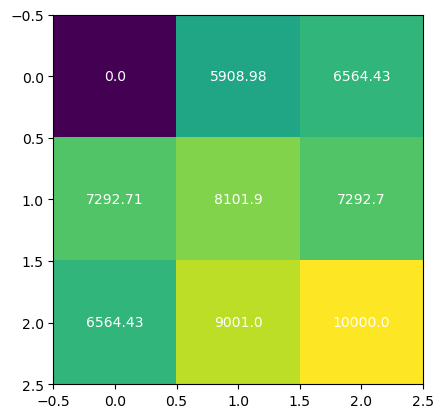

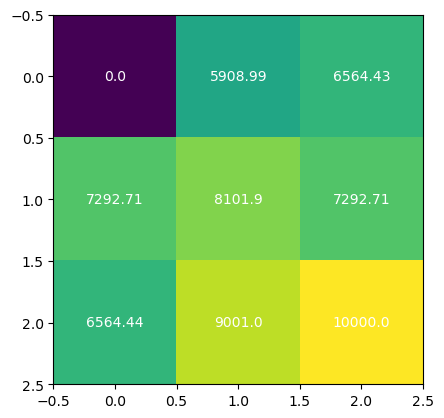

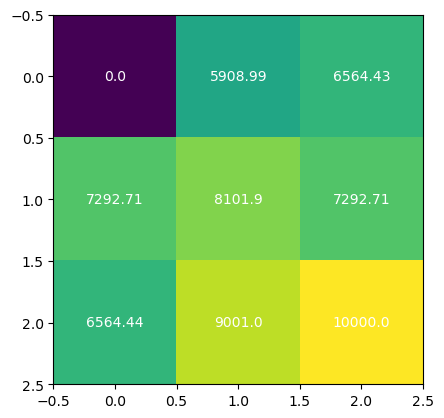

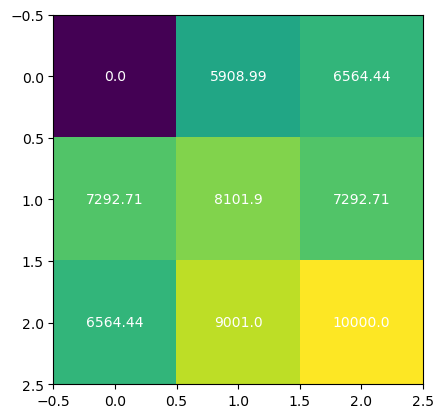

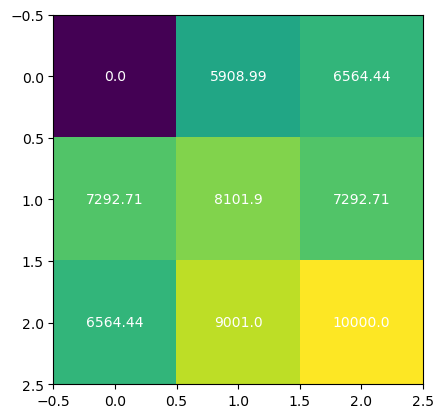

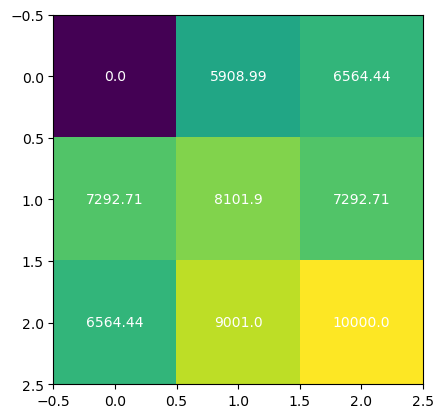

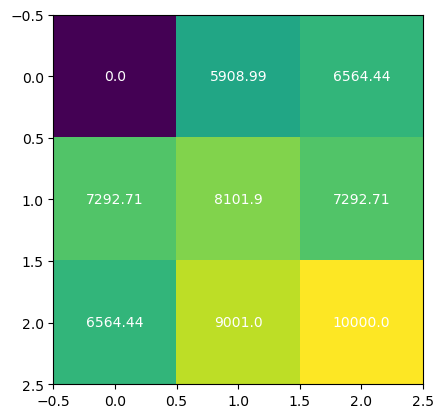

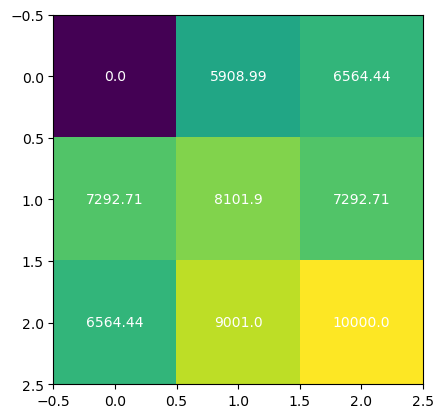

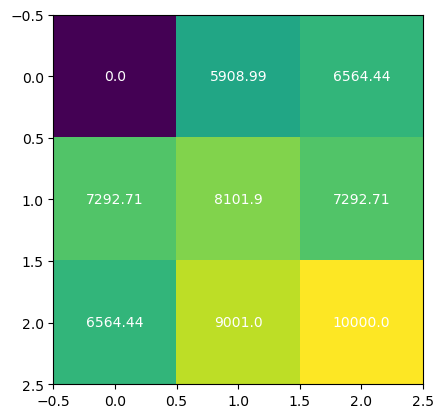

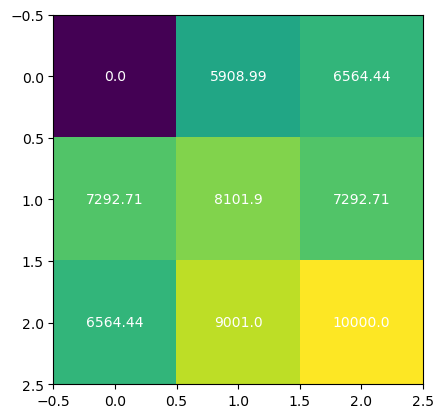

[0, 3, 4, 7, 8]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
 
gamma = 0.9  # 割引率
alpha = 0.1  # 学習率
 
# 報酬の設定
# 移動が可能な場合は1、移動が不可能な場合は0、ゴールとなる8の報酬を10000とする
reward = np.array(
    [
        [0, 1, 0, 1, 0, 0, 0, 0, 0],  # 0から1,3に移動できるので、そこに1
        [1, 0, 1, 0, 0, 0, 0, 0, 0],  # 1から0,2に移動できるので、そこに1
        [0, 1, 0, 0, 0, 1, 0, 0, 0],
        [1, 0, 0, 0, 1, 0, 1, 0, 0],
        [0, 0, 0, 1, 0, 1, 0, 1, 0],
        [0, 0, 1, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 10000],  # 8をゴールより7→8の報酬を大きくする
        [0, 0, 0, 0, 0, 0, 0, 1, 0],
    ]
)
# Q値(行動価値)の初期値を設定。今回は0を初期値とする。
Q = np.array(np.zeros(reward.shape))
# Q学習を実装し、各位置における行動価値を算出
# 以下の学習を実行すると、行動価値Qを求められる。Qの各行が位置に対応し、たとえば0行1列目の値は0から1に移動する行動の価値となる。
 
 
# Q値のヒートマップ作成用関数
def plot_heat_map():
    heat_vec = np.array(np.zeros(len(reward)))
    for k in range(0, len(reward) - 1):
        for l in range(k + 1, len(reward)):
            if reward[k, l] >= 1:
                heat_vec[l] += Q[k, l]
                if k == 4 and l == 5:
                    heat_vec[k] += Q[l, k]
 
    heat_vec[4] /= 2
    heat_vec[5] /= 2
    heat_map = heat_vec.reshape([int(len(reward) ** 0.5), -1])
    fig, ax = plt.subplots()
    im = ax.imshow(heat_map)
    for k in range(int(len(reward) ** 0.5)):
        for l in range(int(len(reward) ** 0.5)):
            text = ax.text(
                l, k, round(heat_map[k, l], 2), ha="center", va="center", color="w"
            )
    plt.show()
 
 
for i in range(200):  # 200エピソードを繰り返し学習を行う
    if i % 5 == 0:  # 5エピソードごとにヒートマップを表示
        plot_heat_map()
 
    current_state = 0  # 初期位置は0
    while current_state != 8:  # 1エピソードが終了するまでのループ
        next_actions = []  # 次の行動の候補を格納するリスト
        for j in range(9):
            if reward[current_state, j] >= 1:
                next_actions.append(j)  # current_stateの状態で移動できる場所を格納
        next_state = np.random.choice(next_actions)  # 行動可能選択肢からランダムに選択
 
        # Q値の更新式
        Q[current_state, next_state] = (1 - alpha) * Q[
            current_state, next_state
        ] + alpha * (
            reward[current_state, next_state]
            + gamma * Q[next_state, np.argmax(Q[next_state,])]
        )
        current_state = next_state  # 次の状態をセット
 
 
# 最短ルート表示関数。Q値が最も高い行動を順番に追加していく
def shortest_path(start):
    path = [start]  # pathに経路を追加していく
    current_pos = start  # current_posは現在位置
    next_pos = -1  # next_pos(次の位置）をてきとうな値で初期化
    while next_pos != 8:  # next_posがゴール（8）になるまで繰り返し行動を選択
        next_pos = np.argmax(Q[current_pos,])  # 各位置の行動価値が最も高い行動を選択
        path.append(next_pos)  # 経路をpathに追加
        current_pos = next_pos  # 行動後が次のcurrent_posとなる
    return path
 
 
print(shortest_path(0))  # スタートを0として最短経路を表示